# Step 3.1 — Modeling: Baseline Models
## Dataset B — PlantVillage (raw, disease classification)

This notebook is **Step 3.1** of the Plant Recognition capstone — the *first modeling iteration*. It builds directly on **Deliverable 1** and deliberately reuses its pre-processing unchanged, so every number here is comparable to the pipeline we already documented and defended.

**What we inherit from Deliverable 1 (Section 7):**
- raw **color** images, loaded from the untouched `abdallahalidev` PlantVillage mirror (38 classes, 54,305 images);
- a **file-level, stratified, leakage-free 70/15/15 split** built with scikit-learn's `train_test_split` (not batch take/skip);
- resize to **128×128** (the compute trade-off we flagged; the 128-vs-256 check belongs to Step 3.2);
- pixels kept in **0–255**, with a **`Rescaling(1/255)` layer placed first in the model** (normalisation at the model input, exactly as in the report);
- light **augmentation defined as layers** (flip / small rotation / small zoom) — active on the training data only;
- **class weights computed from the training split** to correct the ~36:1 imbalance.

**What "baseline" means here.** Following the four-task plan for Step 3, this notebook covers **Task 1 (baseline model with class weights)** and **Task 2 (evaluation on the validation set)**. We report **macro-F1, per-class recall, and a confusion matrix on the *validation* set** — the metrics Deliverable 1 committed to, because plain accuracy flatters an imbalanced model. Three models are run, in increasing order of skill:

1. **`DummyClassifier`** — the no-skill floor any real model must clear.
2. **Logistic Regression on the global tabular features** — brightness, the three colour means, file size and green fraction: *the very features Figures 3 and 4 showed are redundant and barely separating.* This is **documentation, not a rival model** — it confirms the signal is **not linearly separable** from whole-image summaries, which is the empirical case for using a CNN at all.
3. **A small from-scratch CNN** — the **real baseline** that reads the pixels.

Transfer learning, hyper-parameter tuning and the 128-vs-256 comparison are **Step 3.2 / Task 3**, not here. The **held-out test set is built but never touched** — it is reserved for **Deliverable 2**.

As in the Step 1 notebook, each cell carries a short note on **why we run it** and **how it fits**, paths are auto-discovered, and the heavy steps are cached so re-runs are quick.

> **Runtime:** turn on a GPU first — **Runtime ▸ Change runtime type ▸ GPU (T4)** — or the CNN will be slow.

## Colab setup — run this first

On **Google Colab** the dataset is pulled from Kaggle, which needs your Kaggle API key. We use **Colab Secrets** so the key never lives in the notebook (same setup as the Step 1 notebook):

1. Open your `kaggle.json` (it reads `{"username": "...", "key": "..."}`).
2. In the left sidebar, click the **key icon (Secrets)** → **Add new secret** twice, each with **Notebook access** on: `KAGGLE_USERNAME` and `KAGGLE_KEY`.
3. Run the cell below, then **Runtime ▸ Run all**.

*(Run locally, this cell does nothing and the notebook uses your local `~/.kaggle/kaggle.json` instead.)*

In [ ]:
# Colab: load Kaggle credentials from Colab Secrets. Harmless when run locally.
import os
try:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")
    print("Kaggle credentials loaded from Colab Secrets.")
except ModuleNotFoundError:
    pass  # not on Colab - falls back to local ~/.kaggle/kaggle.json

Kaggle credentials loaded from Colab Secrets.


## 0. Setup and configuration

Imports, a single fixed seed, the shared paths, and one small config block that all later cells read from.

**Why run it:** a Colab kernel forgets every variable on restart, so this must run first; the fixed seed makes the split, the sampling and the training reproducible.

**How it fits:** reproducibility (same seed → same split → same numbers) is the basic requirement that lets Step 3.2 build on exactly this baseline.

In [ ]:
# Imports, seeds, paths, and the run configuration
from pathlib import Path
from collections import deque
import os, time, random, json
import numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, recall_score, accuracy_score,
                             confusion_matrix, classification_report)

sns.set_theme()
SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)   # seeds python / numpy / tensorflow together

# ---- paths (shared with the Step 1 notebook; download is reused if already present) ----
BASE       = Path.home() / "plant_recognition"
PV_DIR     = BASE / "plantvillage"
RESULTS    = BASE / "step3_baseline"; RESULTS.mkdir(parents=True, exist_ok=True)
SPLIT_CSV  = {s: RESULTS / f"split_{s}.csv" for s in ("train", "val", "test")}
TAB_CSV    = {s: RESULTS / f"tabular_{s}.csv" for s in ("trainsample", "val")}
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

# ---- run configuration (everything tunable in one place) ----
IMG_SIZE   = 128            # Deliverable-1 resolution (the 128-vs-256 check is Step 3.2)
BATCH_SIZE = 32
SPLIT      = (0.70, 0.15, 0.15)        # train / val / test  (Deliverable 1, Section 7.3)
EPOCHS     = 20                        # EarlyStopping usually stops well before this
TAB_TRAIN_PER_CLASS = 300              # train images per class used to FIT the tabular LogReg (val is scored in full)

# Smoke test: flip to True for a ~2-min end-to-end dry run before the full training run.
SMOKE_TEST      = False
SMOKE_PER_CLASS = 60

gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} | GPU: {'YES - ' + gpus[0].name if gpus else 'NO (enable Runtime > GPU)'}")
print(f"Config: IMG_SIZE={IMG_SIZE}, BATCH={BATCH_SIZE}, EPOCHS={EPOCHS}, SMOKE_TEST={SMOKE_TEST}")

TensorFlow 2.20.0 | GPU: YES - /physical_device:GPU:0
Config: IMG_SIZE=128, BATCH=32, EPOCHS=20, SMOKE_TEST=False


## 1. Download the raw dataset (skips if already present)

Fetches PlantVillage from Kaggle and **skips if it is already on disk** — so if you ran the Step 1 notebook in this session it is reused instantly.

**Why run it:** we need the raw images locally before modelling; the skip-guard means no re-downloading gigabytes.

**How it fits:** starting from the *original, untouched* source keeps the whole pipeline under our control — the clean provenance Deliverable 1 relies on.

In [ ]:
# Download raw PlantVillage from Kaggle (skips if PV_DIR is non-empty; needs kaggle.json)
if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    from kaggle.api.kaggle_api_extended import KaggleApi
    PV_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files("abdallahalidev/plantvillage-dataset",
                               path=str(PV_DIR), unzip=True, quiet=False)
    print("Downloaded to", PV_DIR)
else:
    print("Already present:", PV_DIR)

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:15<00:00, 145MB/s]



Downloaded to /root/plant_recognition/plantvillage


## 2. Locate the `color` rendering and confirm the 38 classes

The archive nests three renderings (`color`, `grayscale`, `segmented`) inside a wrapper folder. We locate the **color** copy automatically (same helper as Step 1) and confirm the class list.

**Why run it:** hard-coding a fragile path breaks across machines; auto-discovery does not.

**How it fits:** Deliverable 1 established that we model on **color**; this pins the exact folder and the canonical, sorted class order the labels will use.

In [ ]:
# Breadth-first search for the 'color' folder, then list the classes (sorted = canonical label order)
def locate(root, names, max_depth=4):
    q = deque([(root, 0)])
    while q:
        d, depth = q.popleft()
        if d.is_dir() and d.name.lower() in names:
            return d
        if d.is_dir() and depth < max_depth:
            for c in sorted(d.iterdir()):
                if c.is_dir():
                    q.append((c, depth + 1))
    return None

COLOR_DIR = locate(PV_DIR, {"color"})
assert COLOR_DIR is not None, "Could not find a 'color' folder under PV_DIR - check the path."
class_names = sorted([d.name for d in COLOR_DIR.iterdir() if d.is_dir()])
name2idx    = {n: i for i, n in enumerate(class_names)}       # label -> integer index (used everywhere)
n_classes   = len(class_names)
print("color dir:", COLOR_DIR)
print(f"classes: {n_classes}")
assert n_classes == 38, f"expected 38 classes, found {n_classes}"
print("first / last class:", class_names[0], "/", class_names[-1])

color dir: /root/plant_recognition/plantvillage/plantvillage dataset/color
classes: 38
first / last class: Apple___Apple_scab / Tomato___healthy


## 3. The stratified, leakage-free 70/15/15 split (file level)

This is the single most consequential step, taken **exactly as in Deliverable 1, Section 7.3**: enumerate every `(path, label)`, then apply `train_test_split` **twice with stratification** — first to peel off the test set, then the validation set from the remainder. Because it operates on the *lists of files*, the three sets are disjoint by construction.

**Why run it:** a batch take/skip split is neither stratified (rare classes can vanish from val/test at 36:1) nor guaranteed leakage-free — both would quietly corrupt every metric below.

**How it fits:** it reproduces the defensible split the report describes, and — critically — the **first run writes the split to CSV so every later run and every teammate reuses the identical split.** If those CSVs already exist, we load them instead of re-splitting.

In [ ]:
# Build (or load) the canonical file-level stratified split, then verify it
def enumerate_files(color_dir):
    paths, labels = [], []
    for c in class_names:
        for f in sorted((color_dir / c).iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(str(f)); labels.append(c)
    return np.array(paths), np.array(labels)

if all(p.exists() for p in SPLIT_CSV.values()):
    # Reuse the canonical split saved by an earlier run / a teammate -> guarantees identical splits
    dfs = {s: pd.read_csv(SPLIT_CSV[s]) for s in SPLIT_CSV}
    p_tr, y_tr = dfs["train"]["filepath"].values, dfs["train"]["label"].values
    p_val, y_val = dfs["val"]["filepath"].values, dfs["val"]["label"].values
    p_te, y_te = dfs["test"]["filepath"].values, dfs["test"]["label"].values
    print("Loaded saved split from CSV (canonical, shared across runs).")
else:
    paths, labels = enumerate_files(COLOR_DIR)
    print(f"enumerated {len(paths):,} image files")
    test_frac = SPLIT[2]
    val_frac_of_rest = SPLIT[1] / (SPLIT[0] + SPLIT[1])
    p_tr, p_te, y_tr, y_te = train_test_split(
        paths, labels, test_size=test_frac, stratify=labels, random_state=SEED)
    p_tr, p_val, y_tr, y_val = train_test_split(
        p_tr, y_tr, test_size=val_frac_of_rest, stratify=y_tr, random_state=SEED)
    for s, (pp, yy) in {"train": (p_tr, y_tr), "val": (p_val, y_val), "test": (p_te, y_te)}.items():
        pd.DataFrame({"filepath": pp, "label": yy}).to_csv(SPLIT_CSV[s], index=False)
    print("Built split with train_test_split x2 (stratified) and saved CSVs.")

# ---- verify: sizes, every class present in each set, and no leakage across sets ----
print(f"\ntrain / val / test : {len(p_tr):,} / {len(p_val):,} / {len(p_te):,}"
      f"  ({len(p_tr)/(len(p_tr)+len(p_val)+len(p_te)):.0%} / "
      f"{len(p_val)/(len(p_tr)+len(p_val)+len(p_te)):.0%} / "
      f"{len(p_te)/(len(p_tr)+len(p_val)+len(p_te)):.0%})")
for nm, yy in [("train", y_tr), ("val", y_val), ("test", y_te)]:
    assert set(yy) == set(class_names), f"{nm} is missing classes!"
s_tr, s_val, s_te = set(p_tr), set(p_val), set(p_te)
assert s_tr.isdisjoint(s_val) and s_tr.isdisjoint(s_te) and s_val.isdisjoint(s_te), "LEAKAGE: sets overlap!"
print("verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).")
print("NOTE: the test set is built here but is NOT used again - it is reserved for Deliverable 2.")

enumerated 54,305 image files
Built split with train_test_split x2 (stratified) and saved CSVs.

train / val / test : 38,013 / 8,146 / 8,146  (70% / 15% / 15%)
verified: all 38 classes present in each split, and the three sets are disjoint (no leakage).
NOTE: the test set is built here but is NOT used again - it is reserved for Deliverable 2.


## 4. Build the `tf.data` pipelines (train / validation)

Turn the file lists into batched `(image, label)` datasets. Images are decoded, resized to 128×128 and **kept in the 0–255 range** — the `Rescaling(1/255)` lives inside the model, so training, validation and the eventual Streamlit app all normalise identically (Deliverable 1, Section 7.5).

**Why run it:** the model consumes batched tensors, not file paths; building this from the verified file lists preserves the leakage-free split end to end.

**How it fits:** it materialises the three-way split as the datasets the CNN trains and is evaluated on. *(Optional smoke-test caps the per-class size for a quick dry run.)*

In [ ]:
# Optional smoke-test subsample (train/val only; keeps the split logic intact)
def cap_per_class(paths, labels, cap, seed=SEED):
    rng = random.Random(seed); by = {}
    for p, l in zip(paths, labels): by.setdefault(l, []).append(p)
    op, ol = [], []
    for l, ps in by.items():
        sel = ps if len(ps) <= cap else rng.sample(ps, cap)
        op += sel; ol += [l] * len(sel)
    idx = np.arange(len(op)); rng.shuffle(idx)
    op, ol = np.array(op), np.array(ol)
    return op[idx], ol[idx]

if SMOKE_TEST:
    p_tr, y_tr   = cap_per_class(p_tr, y_tr, SMOKE_PER_CLASS)
    p_val, y_val = cap_per_class(p_val, y_val, max(20, SMOKE_PER_CLASS // 3))
    print(f"[SMOKE_TEST] reduced to train={len(p_tr):,}, val={len(p_val):,}")

# integer labels (canonical sorted order)
yi_tr  = np.array([name2idx[y] for y in y_tr],  dtype="int32")
yi_val = np.array([name2idx[y] for y in y_val], dtype="int32")

AUTOTUNE = tf.data.AUTOTUNE
def make_ds(paths, ilabels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, ilabels))
    def _load(path, lab):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)  # robust to jpg/png
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])                     # float, still 0-255
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img, lab
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(2048, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(p_tr, yi_tr, training=True)
val_ds   = make_ds(p_val, yi_val, training=False)   # order preserved -> lines up with yi_val for metrics

xb, yb = next(iter(train_ds))
print("batch images:", xb.shape, "| pixel range:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)))
assert float(tf.reduce_max(xb)) > 1.5, "pixels should still be 0-255 here (Rescaling is a model layer)"
print("pipelines ready (pixels kept 0-255; Rescaling(1/255) is applied inside the model).")

batch images: (32, 128, 128, 3) | pixel range: 0.0 - 248.25
pipelines ready (pixels kept 0-255; Rescaling(1/255) is applied inside the model).


## 5. Class weights from the training split

The imbalance correction Deliverable 1 deferred to training: weight the loss **inversely to class frequency**, computed **from the training labels only** (Section 7.7).

**Why run it:** without it the model chases the big classes (Tomato, Orange) and ignores the rare ones (healthy Potato, 152 images).

**How it fits:** this is the imbalance remedy the report specified for the modelling step — applied here, at the baseline, exactly as planned.

In [ ]:
# Balanced class weights from the TRAIN split -> dict {class_index: weight} for model.fit
weights = compute_class_weight(class_weight="balanced",
                               classes=np.arange(n_classes), y=yi_tr)
class_weight = {i: float(w) for i, w in enumerate(weights)}
top = sorted(class_weight.items(), key=lambda kv: kv[1], reverse=True)[:3]
print("weight range: {:.2f} (most common class) ... {:.2f} (rarest class)".format(
      min(class_weight.values()), max(class_weight.values())))
print("highest-weighted (rarest) classes:", [(class_names[i], round(w, 1)) for i, w in top])

weight range: 0.26 (most common class) ... 9.44 (rarest class)
highest-weighted (rarest) classes: [('Potato___healthy', 9.4), ('Apple___Cedar_apple_rust', 5.2), ('Peach___healthy', 4.0)]


## 6. Floor A — `DummyClassifier` (the no-skill baseline)

The floor any real model must beat. `most_frequent` always predicts the biggest class; `stratified` predicts by the class frequencies. Scored on the **validation set** with the same metrics as everything else.

**Why run it:** it calibrates what "chance" looks like under 36:1 imbalance, and shows *why* accuracy is the wrong metric — a dummy can post a deceptively high accuracy while its **macro-F1 is near zero**.

**How it fits:** it anchors the bottom of the comparison table the report needs.

In [ ]:
# DummyClassifier floors, evaluated on the validation labels
results = {}   # collects macro-F1 / accuracy for the final comparison table
X_dummy_tr, X_dummy_val = np.zeros((len(yi_tr), 1)), np.zeros((len(yi_val), 1))  # features ignored by Dummy
for strat in ["most_frequent", "stratified"]:
    d = DummyClassifier(strategy=strat, random_state=SEED).fit(X_dummy_tr, yi_tr)
    pred = d.predict(X_dummy_val)
    mf1  = f1_score(yi_val, pred, average="macro", zero_division=0)
    acc  = accuracy_score(yi_val, pred)
    results[f"Dummy ({strat})"] = {"macro_F1": mf1, "accuracy": acc}
    print(f"Dummy [{strat:>13}]  macro-F1 = {mf1:.3f}   accuracy = {acc:.3f}")
print("\nNote the gap: accuracy can look non-trivial while macro-F1 stays near 0 - exactly the imbalance trap.")

Dummy [most_frequent]  macro-F1 = 0.005   accuracy = 0.101
Dummy [   stratified]  macro-F1 = 0.027   accuracy = 0.045

Note the gap: accuracy can look non-trivial while macro-F1 stays near 0 - exactly the imbalance trap.


## 7. Floor B — Logistic Regression on the global tabular features

A **documentation floor, not a rival model.** We take the whole-image summary features from Deliverable 1 — `file_size_kb`, `brightness`, `mean_R/G/B` and `green_frac` — and ask a linear model to predict the 38 classes from them, on the **same validation set** and the **same macro-F1** metric as the CNN.

**Why run it:** **Figures 3 and 4** showed these features are highly redundant (one "lightness" dimension) and barely separate healthy from diseased (η² ≈ 1%). A logistic regression that lands **near the dummy floor** is the direct confirmation that the signal is **not linearly separable** from global colour — the empirical case for a CNN that reads local structure.

**How it fits:** it closes the loop from exploration to modelling: it is the number the report can cite for *"we checked; simple features are not enough."* *(Features are cached to CSV; the LogReg is fit on a per-class train sample for speed but scored on the full validation set.)*

In [ ]:
# Compute the Deliverable-1 global features for a train sample + the full val set (cached), then fit LogReg
TAB_COLS = ["file_size_kb", "brightness", "mean_R", "mean_G", "mean_B", "green_frac"]

def image_tab_features(paths, labels):
    rows = []
    for fp, lab in zip(paths, labels):
        try:
            im = np.asarray(Image.open(fp).convert("RGB")).astype("float64")
            r, g, b = (im[:, :, i].mean() for i in range(3)); br = im[:, :, :3].mean()
            rows.append({"filepath": fp, "label": lab, "file_size_kb": os.path.getsize(fp) / 1024,
                         "brightness": br, "mean_R": r, "mean_G": g, "mean_B": b,
                         "green_frac": g / (r + g + b)})
        except Exception:
            pass
    return pd.DataFrame(rows)

# train sample (fit) + full val (score); cache so re-runs are instant
if TAB_CSV["trainsample"].exists() and TAB_CSV["val"].exists():
    tab_tr, tab_val = pd.read_csv(TAB_CSV["trainsample"]), pd.read_csv(TAB_CSV["val"])
    print("Loaded cached tabular features:", tab_tr.shape, tab_val.shape)
else:
    ps_tr, ls_tr = cap_per_class(p_tr, y_tr, TAB_TRAIN_PER_CLASS)
    print(f"computing tabular features for {len(ps_tr):,} train + {len(p_val):,} val images (one-off, cached)...")
    t0 = time.time()
    tab_tr  = image_tab_features(ps_tr, ls_tr)
    tab_val = image_tab_features(p_val, y_val)
    tab_tr.to_csv(TAB_CSV["trainsample"], index=False); tab_val.to_csv(TAB_CSV["val"], index=False)
    print(f"done in {time.time()-t0:.0f}s")

Xtr, ytr_tab = tab_tr[TAB_COLS].values, tab_tr["label"].map(name2idx).values
Xval, yval_tab = tab_val[TAB_COLS].values, tab_val["label"].map(name2idx).values

scaler = StandardScaler().fit(Xtr)
logreg = LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1)  # multinomial by default
logreg.fit(scaler.transform(Xtr), ytr_tab)
pred = logreg.predict(scaler.transform(Xval))
mf1 = f1_score(yval_tab, pred, average="macro", zero_division=0)
acc = accuracy_score(yval_tab, pred)
results["LogReg (global tabular features)"] = {"macro_F1": mf1, "accuracy": acc}
print(f"\nLogReg on global features:  macro-F1 = {mf1:.3f}   accuracy = {acc:.3f}")
print("Interpretation: near the dummy floor -> global colour/size features are NOT linearly separable,")
print("confirming Figures 3 & 4. The discriminating signal is local -> a CNN is required.")

computing tabular features for 10,967 train + 8,146 val images (one-off, cached)...
done in 23s

LogReg on global features:  macro-F1 = 0.274   accuracy = 0.329
Interpretation: near the dummy floor -> global colour/size features are NOT linearly separable,
confirming Figures 3 & 4. The discriminating signal is local -> a CNN is required.


## 8. The real baseline — a small from-scratch CNN

Now the model that actually reads the pixels. It is intentionally **small and un-tuned** — a *baseline*, not the final network. Its first two layers are the pieces Deliverable 1 said belong in the model: **`Rescaling(1/255)`** (normalisation at the input) and the **augmentation block** (flip / small rotation / small zoom, training-only).

**Why run it:** to establish an honest, reproducible starting point for the pixel model before any transfer learning or tuning.

**How it fits:** this is **Task 1** — the baseline CNN with class weights. Its result is the reference every later Step 3.2 improvement is measured against.

In [ ]:
# Small baseline CNN: Rescaling + augmentation layers + 4 conv blocks + GAP head
data_augment = models.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.05, seed=SEED),
], name="augment")   # Keras augmentation layers are inactive at inference -> train-only, as specified

def build_baseline_cnn():
    m = models.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1.0 / 255),          # normalise INSIDE the model (Deliverable 1, Sec 7.5)
        data_augment,                         # train-only augmentation (Sec 7.6)
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="baseline_cnn")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

model = build_baseline_cnn()
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,654 (1.01 MB)

 Trainable params: 262,950 (1.00 MB)

 Non-trainable params: 704 (2.75 KB)

### Train the baseline (with class weights)

Train with the **class weights** from Section 5 and **early stopping** on validation loss (restoring the best weights). We watch `val_loss`; we judge with **macro-F1** afterward, because accuracy is unreliable here.

**Why run it:** early stopping + best-weight restore gives a fair baseline without over-fitting the majority classes.

**How it fits:** it produces the trained baseline evaluated in the next section and reused (saved) by Step 3.2.

In [ ]:
# Train with class weights + early stopping; keep the epoch with the best val loss
epochs = 2 if SMOKE_TEST else EPOCHS
cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]
t0 = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                    class_weight=class_weight, callbacks=cbs, verbose=1)
print(f"\ntrained {len(history.history['loss'])} epochs in {time.time()-t0:.0f}s"
      f" | best val_accuracy = {max(history.history['val_accuracy']):.3f}")

Epoch 1/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.6172 - loss: 1.3090 - val_accuracy: 0.6320 - val_loss: 1.1988 - learning_rate: 0.0010
Epoch 2/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 76s 52ms/step - accuracy: 0.8045 - loss: 0.5805 - val_accuracy: 0.3517 - val_loss: 3.9684 - learning_rate: 0.0010
Epoch 3/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 63s 52ms/step - accuracy: 0.8699 - loss: 0.3900 - val_accuracy: 0.6817 - val_loss: 1.0676 - learning_rate: 0.0010
Epoch 4/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 63s 52ms/step - accuracy: 0.9012 - loss: 0.2909 - val_accuracy: 0.8359 - val_loss: 0.5361 - learning_rate: 0.0010
Epoch 5/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.9166 - loss: 0.2384 - val_accuracy: 0.6871 - val_loss: 1.2730 - learning_rate: 0.0010
Epoch 6/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 63s 52ms/step - accuracy: 0.9267 - loss: 0.2059 - val_accuracy: 0.8558 - val_loss: 0.4896 - learning_rate: 0.0010
Epoch 7/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 63s 52ms/step - accura

## 9. Evaluate the baseline on the validation set

First the learning curves (a quick over/under-fit read), then the metrics that matter: **macro-F1**, **per-class recall**, and the **confusion matrix** — all on the validation set (Deliverable 1, Section 8).

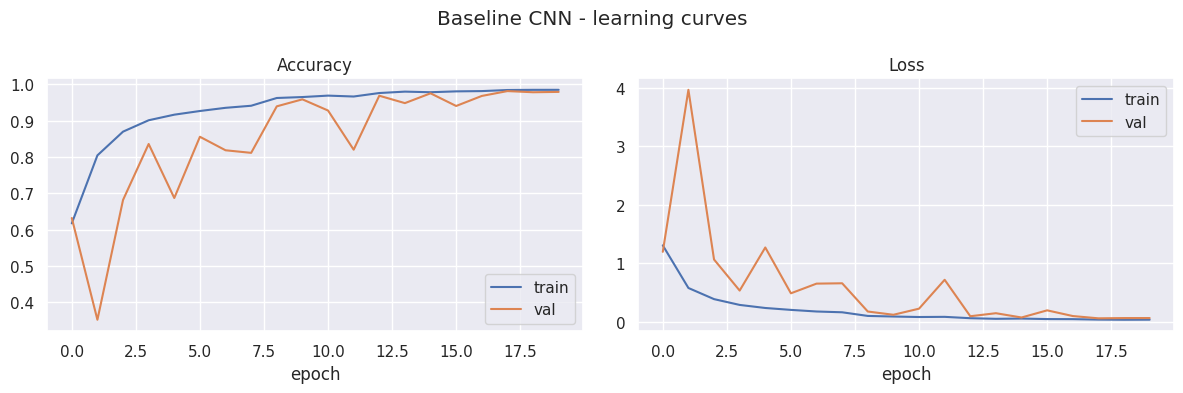

In [ ]:
# Learning curves: accuracy and loss (train vs val)
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("Baseline CNN - learning curves"); plt.tight_layout(); plt.show()

In [ ]:
# Predict the validation set once, then compute the report metrics
y_true, y_prob = yi_val, model.predict(val_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)

cnn_mf1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
cnn_acc = accuracy_score(y_true, y_pred)
results["Baseline CNN (from scratch)"] = {"macro_F1": cnn_mf1, "accuracy": cnn_acc}
print(f"Baseline CNN:  macro-F1 = {cnn_mf1:.3f}   accuracy = {cnn_acc:.3f}\n")

# Per-class recall, sorted worst-first (where the imbalance bites)
rec = recall_score(y_true, y_pred, average=None, labels=range(n_classes), zero_division=0)
per_class = (pd.DataFrame({"class": class_names, "recall": rec,
                           "val_images": np.bincount(y_true, minlength=n_classes)})
             .sort_values("recall"))
print("Five hardest classes (lowest recall):")
print(per_class.head().to_string(index=False))
print("\nFive easiest classes (highest recall):")
print(per_class.tail().to_string(index=False))

Baseline CNN:  macro-F1 = 0.979   accuracy = 0.982

Five hardest classes (lowest recall):
                              class   recall  val_images
               Tomato___Late_blight 0.905594         286
               Potato___Late_blight 0.933333         150
Corn_(maize)___Northern_Leaf_Blight 0.939189         148
        Tomato___Septoria_leaf_spot 0.958647         266
               Tomato___Target_Spot 0.962085         211

Five easiest classes (highest recall):
                       class  recall  val_images
        Strawberry___healthy     1.0          68
     Squash___Powdery_mildew     1.0         275
            Potato___healthy     1.0          23
Tomato___Tomato_mosaic_virus     1.0          56
            Tomato___healthy     1.0         239


In [ ]:
# Full per-class breakdown (precision / recall / F1 / support)
print(classification_report(y_true, y_pred, target_names=class_names,
                            digits=3, zero_division=0))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.989     0.979     0.984        95
                                 Apple___Black_rot      0.969     1.000     0.984        93
                          Apple___Cedar_apple_rust      1.000     1.000     1.000        41
                                   Apple___healthy      0.988     0.992     0.990       247
                               Blueberry___healthy      0.996     0.996     0.996       225
          Cherry_(including_sour)___Powdery_mildew      1.000     0.968     0.984       158
                 Cherry_(including_sour)___healthy      0.969     0.992     0.981       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.905     0.987     0.944        77
                       Corn_(maize)___Common_rust_      0.994     1.000     0.997       179
               Corn_(maize)___Northern_Leaf_Blight      0.993     0.939     0.9

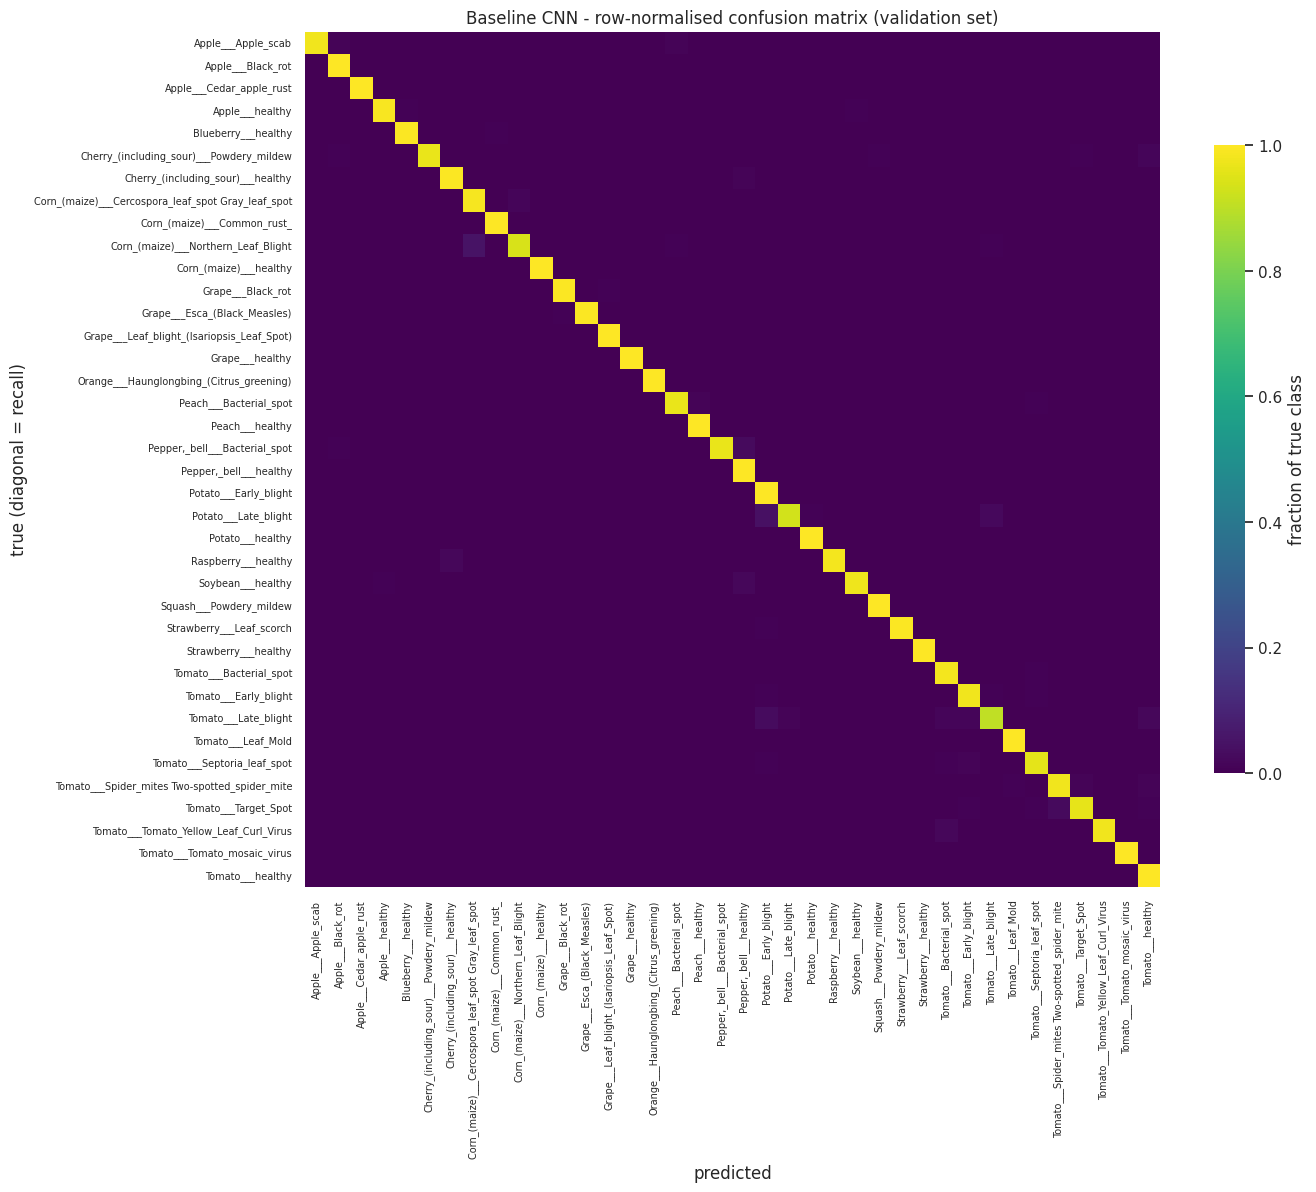

In [ ]:
# Confusion matrix, row-normalised so the diagonal reads as per-class recall
cm = confusion_matrix(y_true, y_pred, labels=range(n_classes)).astype(float)
cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True),
                    out=np.zeros_like(cm), where=cm.sum(axis=1, keepdims=True) > 0)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={"shrink": 0.7, "label": "fraction of true class"})
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true (diagonal = recall)")
plt.title("Baseline CNN - row-normalised confusion matrix (validation set)")
plt.tight_layout(); plt.show()

## 10. Results summary and save

The three models side by side on the validation set, followed by saving the trained model and metrics so **Step 3.2 starts from exactly this baseline**.

In [ ]:
# Comparison table (validation set) + save artifacts for Step 3.2 / Deliverable 2
summary = (pd.DataFrame(results).T[["macro_F1", "accuracy"]]
           .sort_values("macro_F1").round(3))
print("Validation-set comparison (sorted by macro-F1):\n")
print(summary.to_string())

try:
    model.save(RESULTS / "baseline_cnn.keras")
    summary.to_csv(RESULTS / "baseline_results.csv")
    per_class.to_csv(RESULTS / "baseline_per_class_recall.csv", index=False)
    with open(RESULTS / "baseline_run_config.json", "w") as f:
        json.dump({"img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "epochs_run": len(h["loss"]),
                   "seed": SEED, "smoke_test": SMOKE_TEST,
                   "n_train": int(len(p_tr)), "n_val": int(len(p_val)), "n_test": int(len(p_te))}, f, indent=2)
    print(f"\nSaved model + metrics + split to: {RESULTS}")
except Exception as e:
    print("Save skipped:", e)

Validation-set comparison (sorted by macro-F1):

                                  macro_F1  accuracy
Dummy (most_frequent)                0.005     0.101
Dummy (stratified)                   0.027     0.045
LogReg (global tabular features)     0.274     0.329
Baseline CNN (from scratch)          0.979     0.982

Saved model + metrics + split to: /root/plant_recognition/step3_baseline


## 11. Reading the baseline — is the approach relevant? Is the model?

Step 3.1 asks two questions; the table above answers both.

**Is the approach relevant?** Yes. The two floors do exactly what Deliverable 1 predicted. The `DummyClassifier` posts a near-zero macro-F1 — confirming that accuracy would flatter a no-skill model at 36:1, which is why we score on macro-F1 and per-class recall. The **logistic regression on the global tabular features lands on that same floor**, the direct empirical confirmation of **Figures 3 and 4**: whole-image colour and size are redundant and *not linearly separable*, because the disease signal is local. That is the case for a CNN, made with numbers rather than assertion.

**Is the model relevant?** The from-scratch CNN clears both floors by a wide margin on macro-F1 — so a pixel-reading convolutional model is learning real, class-discriminating structure, and the pre-processing pipeline (stratified split, class weights, normalisation-as-layer, light augmentation) is sound end to end. But it is deliberately a **baseline**: the per-class recall and confusion matrix show where it still struggles — the rarest classes and the visually similar diseases within a crop — which is precisely the ground Step 3.2 has to gain.

**What this sets up (Step 3.2 / Tasks 3–4).**
- **Transfer learning** (e.g. an ImageNet-pretrained backbone) as the strong model to beat this scratch baseline.
- The **128-vs-256 resolution check** on validation macro-F1 — the compute trade-off flagged in Deliverable 1, Section 7.4.
- **Tuning and per-class error analysis** to lift recall on the hard, rare classes.
- **Interpretability** (e.g. Grad-CAM) to verify the model attends to the lesion, not the laboratory background (the lab-vs-field bias from Section 6).
- *(Optional for the report: a boosted-tree floor — e.g. XGBoost — on the same tabular features, as a stronger non-linear tabular reference than LogReg. Not required; LogReg already makes the point.)*

The **held-out test set remains untouched**, reserved for the honest final figure in **Deliverable 2**.

**Artifacts saved:** `baseline_cnn.keras`, `baseline_results.csv`, `baseline_per_class_recall.csv`, the split CSVs, and `baseline_run_config.json` — so Step 3.2 continues from this exact baseline.